In [2]:
import pandas as pd
df = pd.read_csv("loanapproval.csv")

print("DATASET INFO")
print(df.info())

print("\nDATASET SHAPE")
print("Rows, Columns:", df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nNUMERICAL DESCRIPTION")
print(df.describe())

print("\nFULL DESCRIPTION")
print(df.describe(include='all'))

print("\nUNIQUE VALUES COUNT")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

print("\nUNIQUE VALUES IN EACH COLUMN")
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())

print("\nVALUE COUNTS")
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   applicant_id          1000 non-null   int64 
 1   age                   1000 non-null   int64 
 2   gender                1000 non-null   object
 3   marital_status        1000 non-null   object
 4   annual_income         1000 non-null   int64 
 5   loan_amount           1000 non-null   int64 
 6   credit_score          1000 non-null   int64 
 7   num_dependents        1000 non-null   int64 
 8   existing_loans_count  1000 non-null   int64 
 9   employment_status     1000 non-null   object
 10  loan_approved         1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB
None

DATASET SHAPE
Rows, Columns: (1000, 11)

COLUMN NAMES
Index(['applicant_id', 'age', 'gender', 'marital_status', 'annual_income',
       'loan_amount', 'credit_score', 'num_de

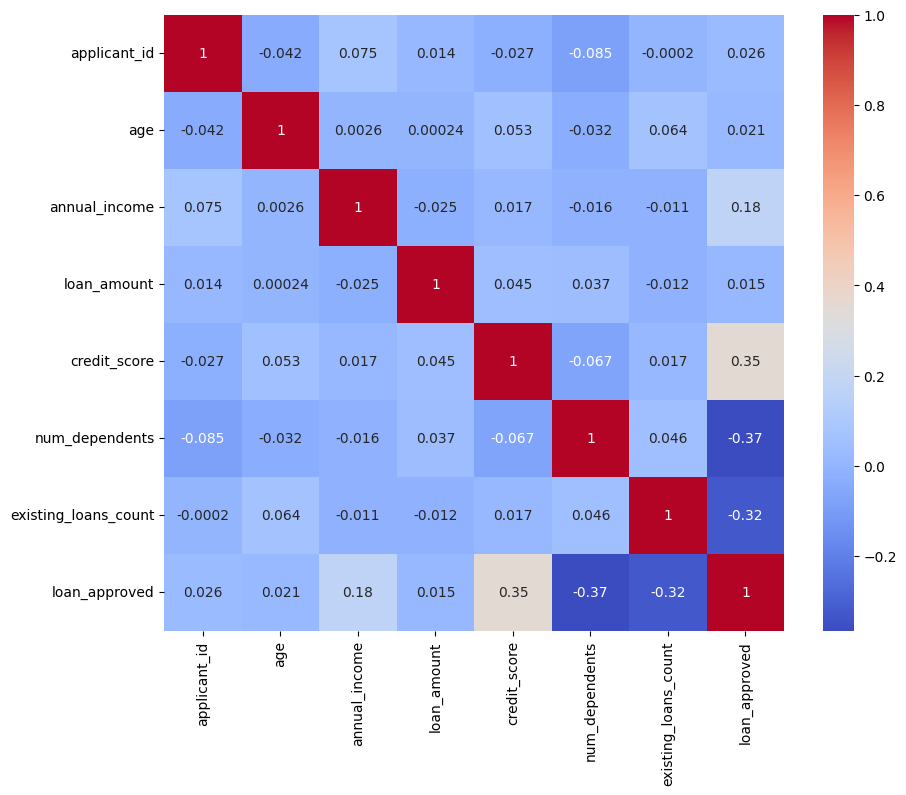

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

[ 9127.5 31663.  38912.  41641.5]
                         Bin  Count  Count (%)  Non-event  Event  Event rate  \
0            (-inf, 9127.50)    102      0.102         24     78    0.764706   
1        [9127.50, 31663.00)    510      0.510        136    374    0.733333   
2       [31663.00, 38912.00)    157      0.157         50    107    0.681529   
3       [38912.00, 41641.50)     54      0.054         22     32    0.592593   
4            [41641.50, inf)    177      0.177         39    138    0.779661   
5                    Special      0      0.000          0      0    0.000000   
6                    Missing      0      0.000          0      0    0.000000   
Totals                         1000      1.000        271    729    0.729000   

             WoE        IV        JS  
0        -0.1891  0.003486  0.000435  
1      -0.022046  0.000247  0.000031  
2       0.228749  0.008630  0.001076  
3       0.614861  0.022925  0.002821  
4      -0.274137  0.012443  0.001550  
5          

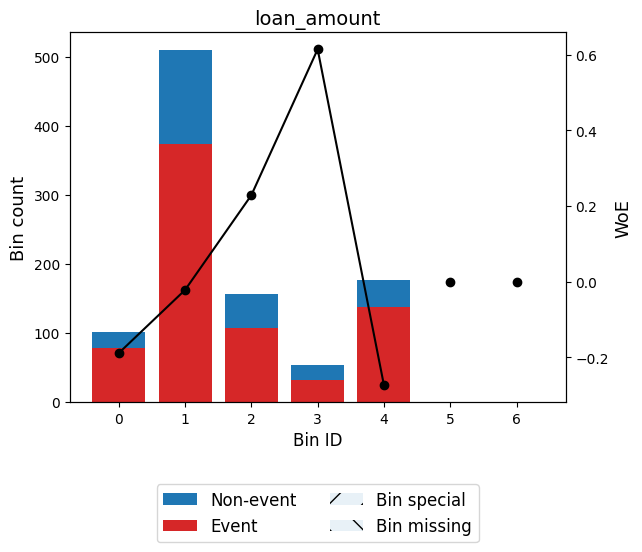

None


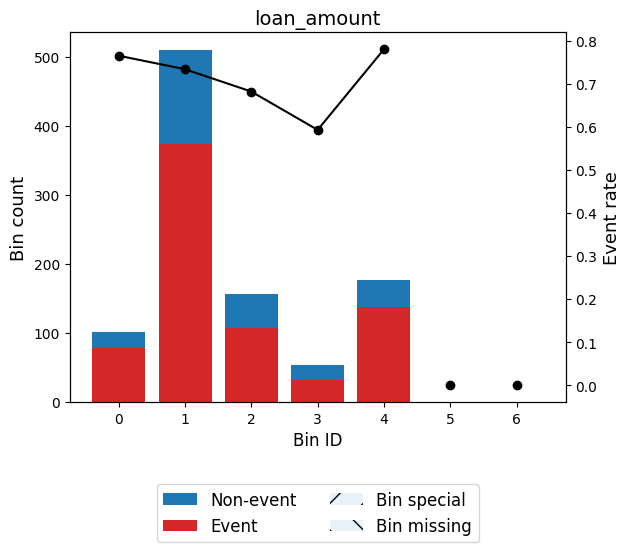

None


In [10]:
import numpy as np
import pandas as pd

df = pd.read_csv("loanapproval.csv")

target = "loan_approved"
variable = "loan_amount"
x = df[variable].values
y = df[target]

from optbinning import OptimalBinning
optb = OptimalBinning(name=variable,dtype='numerical',solver='cp')

optb.fit(x,y)

optb.status

print(optb.splits)

binning_table = optb.binning_table

print(binning_table.build())

print(binning_table.plot(metric='woe'))

print(binning_table.plot(metric='event_rate'))

[ 26608.5  40084.5 121313.5]
                          Bin  Count  Count (%)  Non-event  Event  Event rate  \
0            (-inf, 26608.50)     54      0.054         30     24    0.444444   
1        [26608.50, 40084.50)    132      0.132         68     64    0.484848   
2       [40084.50, 121313.50)    628      0.628        141    487    0.775478   
3            [121313.50, inf)    186      0.186         32    154    0.827957   
4                     Special      0      0.000          0      0    0.000000   
5                     Missing      0      0.000          0      0    0.000000   
Totals                          1000      1.000        271    729    0.729000   

             WoE        IV        JS  
0       1.212698  0.094323  0.011117  
1        1.05018  0.171317  0.020482  
2      -0.249949  0.036928  0.004604  
3      -0.581662  0.054192  0.006680  
4            0.0  0.000000  0.000000  
5            0.0  0.000000  0.000000  
Totals            0.356760  0.042883  


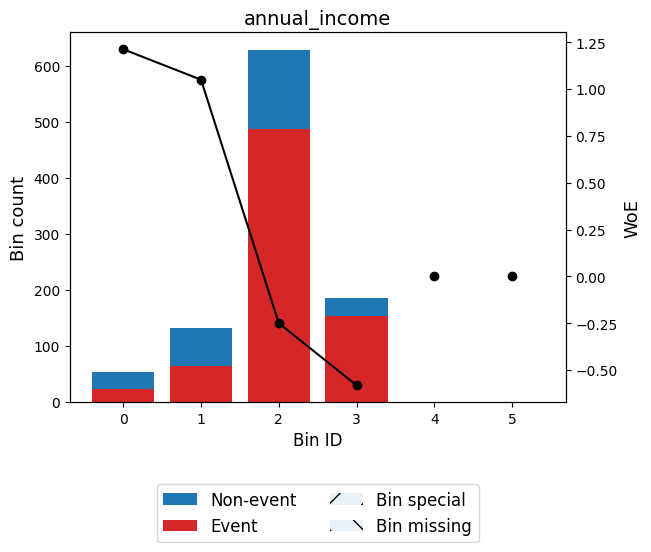

None


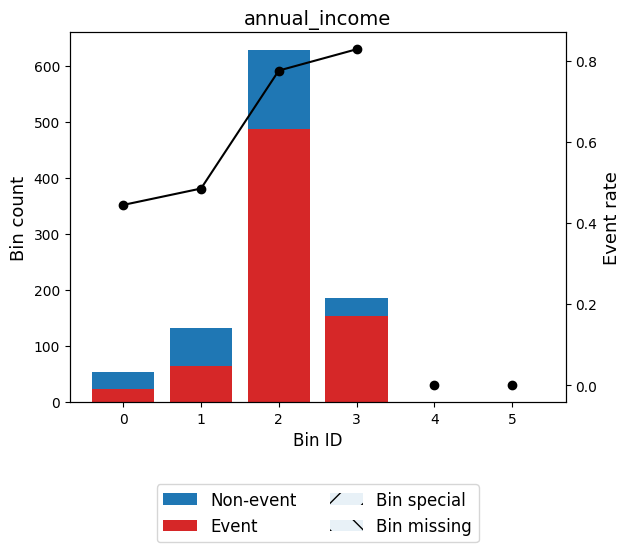

None


In [21]:
import numpy as np
import pandas as pd

df = pd.read_csv("loanapproval.csv")

target = "loan_approved"
variable = "annual_income"
x = df[variable].values
y = df[target]

from optbinning import OptimalBinning
optb = OptimalBinning(name=variable,dtype='numerical',solver='cp')

optb.fit(x,y)

optb.status

print(optb.splits)

binning_table = optb.binning_table

print(binning_table.build())

print(binning_table.plot(metric='woe'))

print(binning_table.plot(metric='event_rate'))

[341.5 502.5 547.5 597.5 632.5 743.5]
                     Bin  Count  Count (%)  Non-event  Event  Event rate  \
0         (-inf, 341.50)     65      0.065         24     41    0.630769   
1       [341.50, 502.50)    299      0.299        130    169    0.565217   
2       [502.50, 547.50)     95      0.095         51     44    0.463158   
3       [547.50, 597.50)     87      0.087         31     56    0.643678   
4       [597.50, 632.50)     54      0.054          7     47    0.870370   
5       [632.50, 743.50)    208      0.208         17    191    0.918269   
6          [743.50, inf)    192      0.192         11    181    0.942708   
7                Special      0      0.000          0      0    0.000000   
8                Missing      0      0.000          0      0    0.000000   
Totals                     1000      1.000        271    729    0.729000   

             WoE        IV        JS  
0       0.454037  0.014674  0.001819  
1       0.727191  0.180256  0.022048  
2       

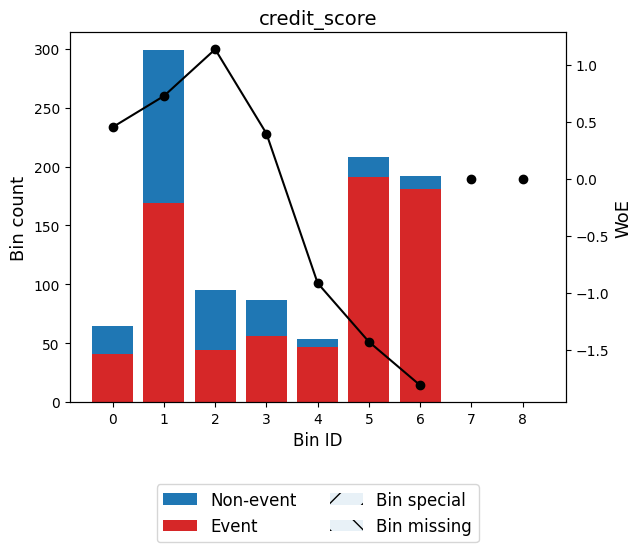

None


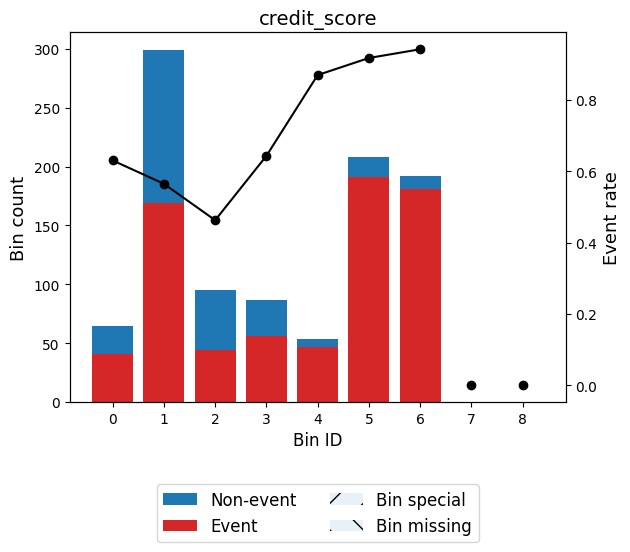

None


In [22]:
import numpy as np
import pandas as pd

df = pd.read_csv("loanapproval.csv")

target = "loan_approved"
variable = "credit_score"
x = df[variable].values
y = df[target]

from optbinning import OptimalBinning
optb = OptimalBinning(name=variable,dtype='numerical',solver='cp')

optb.fit(x,y)

optb.status

print(optb.splits)

binning_table = optb.binning_table

print(binning_table.build())

print(binning_table.plot(metric='woe'))

print(binning_table.plot(metric='event_rate'))

[1.5 2.5]
                 Bin  Count  Count (%)  Non-event  Event  Event rate  \
0       (-inf, 1.50)    406      0.406         47    359    0.884236   
1       [1.50, 2.50)    204      0.204         26    178    0.872549   
2        [2.50, inf)    390      0.390        198    192    0.492308   
3            Special      0      0.000          0      0    0.000000   
4            Missing      0      0.000          0      0    0.000000   
Totals                 1000      1.000        271    729    0.729000   

             WoE        IV        JS  
0       -1.04362  0.332939  0.039826  
1      -0.934132  0.138466  0.016705  
2       1.020327  0.476750  0.057136  
3            0.0  0.000000  0.000000  
4            0.0  0.000000  0.000000  
Totals            0.948156  0.113667  


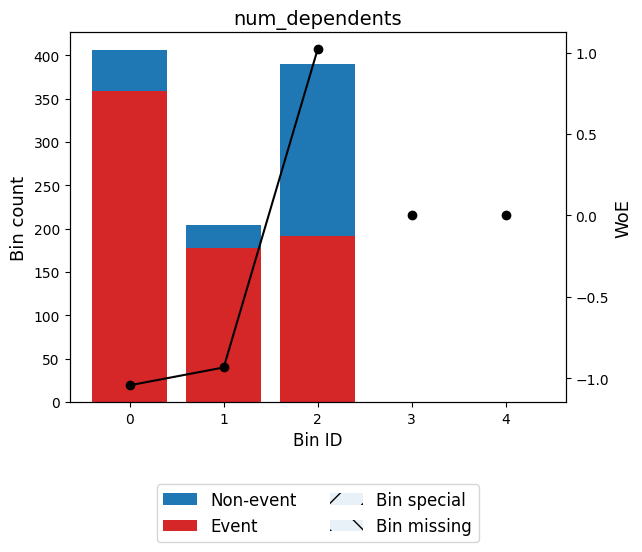

None


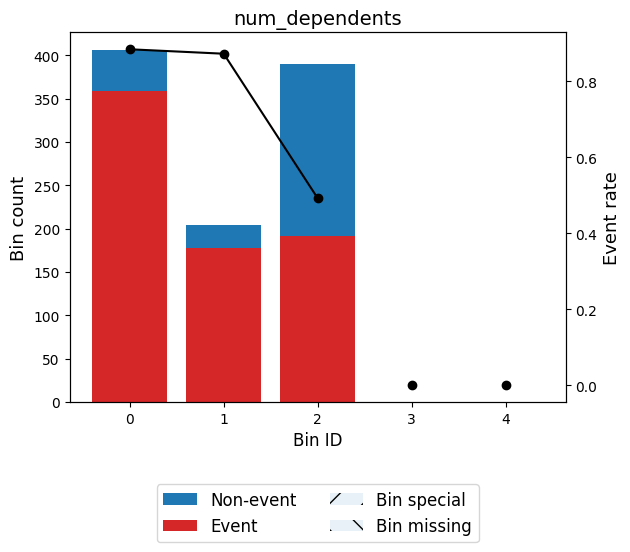

None


In [23]:
import numpy as np
import pandas as pd

df = pd.read_csv("loanapproval.csv")

target = "loan_approved"
variable = "num_dependents"
x = df[variable].values
y = df[target]

from optbinning import OptimalBinning
optb = OptimalBinning(name=variable,dtype='numerical',solver='cp')

optb.fit(x,y)

optb.status

print(optb.splits)

binning_table = optb.binning_table

print(binning_table.build())

print(binning_table.plot(metric='woe'))

print(binning_table.plot(metric='event_rate'))

[2.5 3.5]
                 Bin  Count  Count (%)  Non-event  Event  Event rate  \
0       (-inf, 2.50)    583      0.583         76    507    0.869640   
1       [2.50, 3.50)    205      0.205         96    109    0.531707   
2        [3.50, inf)    212      0.212         99    113    0.533019   
3            Special      0      0.000          0      0    0.000000   
4            Missing      0      0.000          0      0    0.000000   
Totals                 1000      1.000        271    729    0.729000   

             WoE        IV        JS  
0      -0.908223  0.376940  0.045562  
1       0.862555  0.176585  0.021413  
2       0.857287  0.180293  0.021871  
3            0.0  0.000000  0.000000  
4            0.0  0.000000  0.000000  
Totals            0.733819  0.088846  


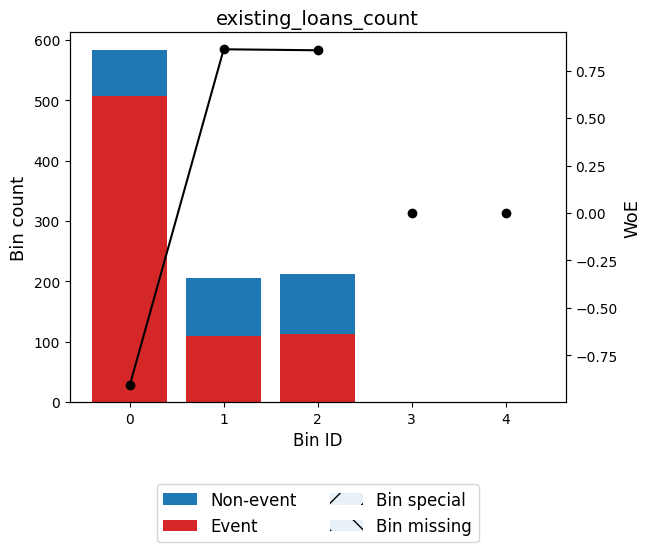

None


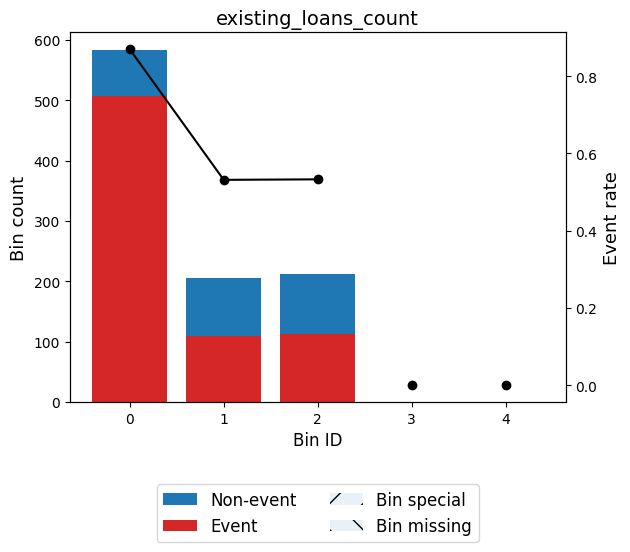

None


In [24]:
import numpy as np
import pandas as pd

df = pd.read_csv("loanapproval.csv")

target = "loan_approved"
variable = "existing_loans_count"
x = df[variable].values
y = df[target]

from optbinning import OptimalBinning
optb = OptimalBinning(name=variable,dtype='numerical',solver='cp')

optb.fit(x,y)

optb.status

print(optb.splits)

binning_table = optb.binning_table

print(binning_table.build())

print(binning_table.plot(metric='woe'))

print(binning_table.plot(metric='event_rate'))

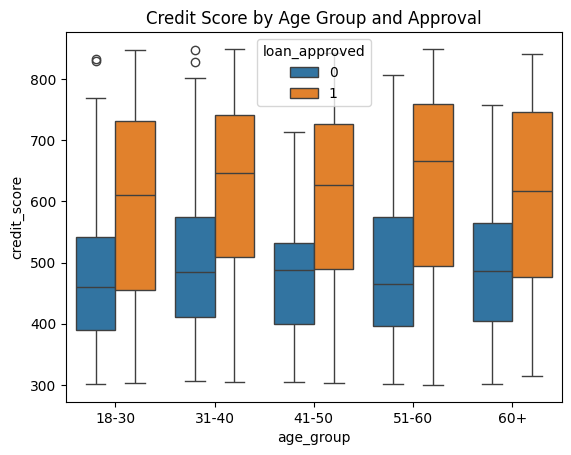

In [ ]:
# 1.Credit score vs approval at different age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[18,30,40,50,60,100],
    labels=['18-30','31-40','41-50','51-60','60+']
)

sns.boxplot(
    x='age_group',
    y='credit_score',
    hue='loan_approved',
    data=df
)

plt.title('Credit Score by Age Group and Approval')
plt.show()

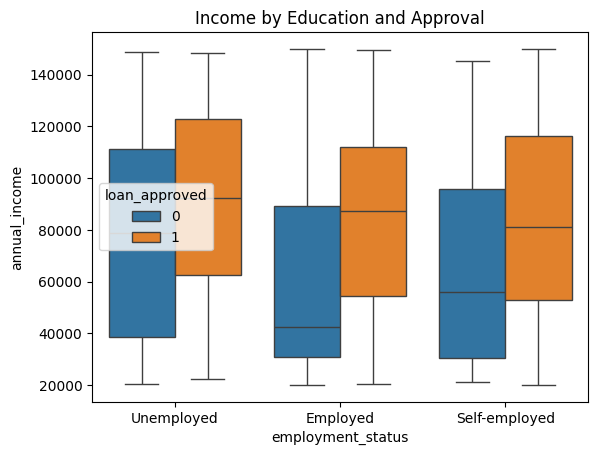

In [ ]:
# 2.Income vs approval across employment status
sns.boxplot(
    x='employment_status',
    y='annual_income',
    hue='loan_approved',
    data=df
)

plt.title('Income by Education and Approval')
plt.show()

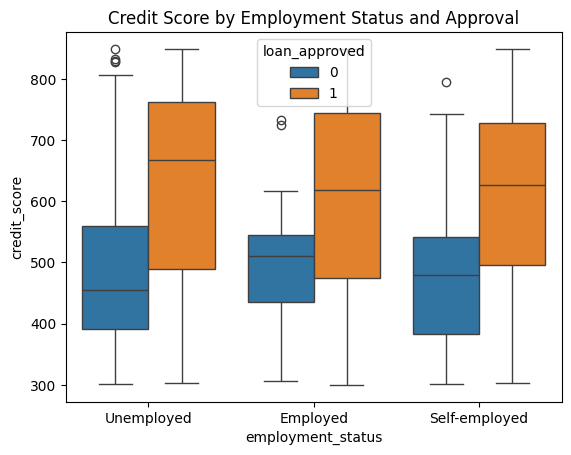

In [ ]:
# 3.Credit score vs approval across employment status
sns.boxplot(
    data=df,
    x='employment_status',
    y='credit_score',
    hue='loan_approved'
)

plt.title('Credit Score by Employment Status and Approval')
plt.show()

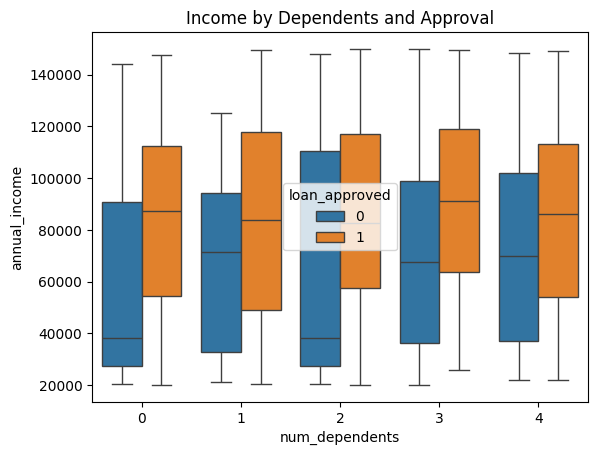

In [ ]:
# 4.Income vs approval across number of dependents
sns.boxplot(
    data=df,
    x='num_dependents',
    y='annual_income',
    hue='loan_approved'
)

plt.title('Income by Dependents and Approval')
plt.show()

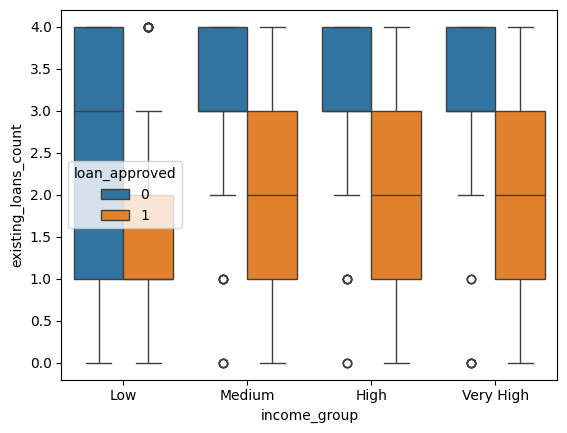

In [ ]:
# 5.Existing loans vs approval across income groups
df['income_group'] = pd.qcut(
    df['annual_income'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

sns.boxplot(
    data=df,
    x='income_group',
    y='existing_loans_count',
    hue='loan_approved'
)

plt.show()

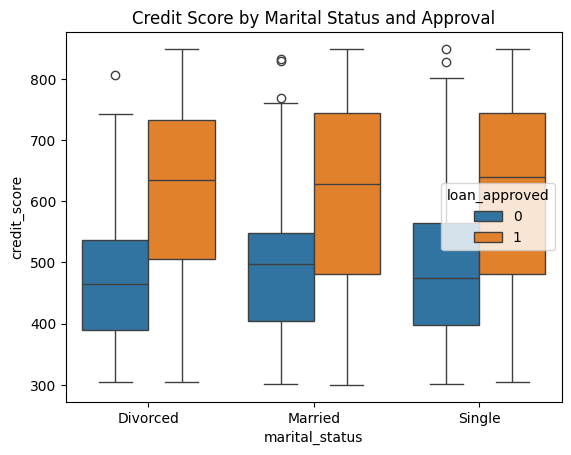

In [ ]:
# 6.Credit score vs approval across marital status
sns.boxplot(
    data=df,
    x='marital_status',
    y='credit_score',
    hue='loan_approved'
)

plt.title('Credit Score by Marital Status and Approval')
plt.show()

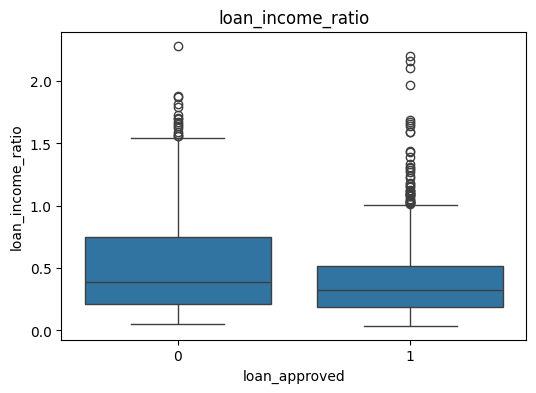

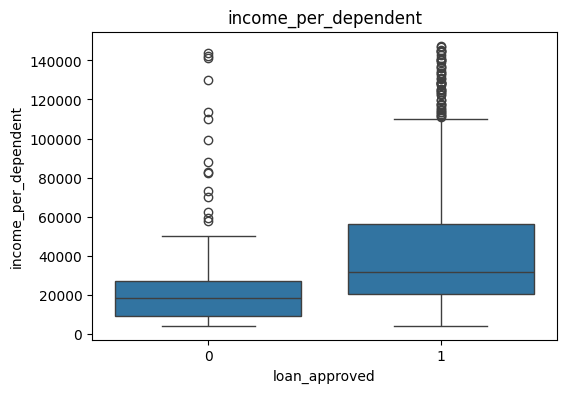

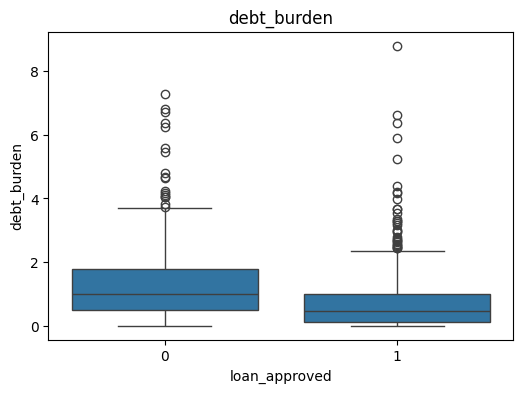

     applicant_id  age  gender marital_status  annual_income  loan_amount  \
0               1   59    Male       Divorced         100073         7169   
1               2   49    Male        Married         112197        23556   
2               3   35    Male       Divorced          84429        27052   
3               4   63  Female         Single         124195        11313   
4               5   28  Female        Married          81627        13315   
..            ...  ...     ...            ...            ...          ...   
995           996   53  Female        Married         135598         6014   
996           997   22    Male         Single         139028        15103   
997           998   34  Female        Married         147517        21986   
998           999   60  Female       Divorced          73161        49781   
999          1000   60  Female         Single         141316        35471   

     credit_score  num_dependents  existing_loans_count employment_status  

In [48]:
# derived features
df['loan_income_ratio'] = (
    df['loan_amount'] / df['annual_income']
)

df['income_per_dependent'] = (
    df['annual_income'] /
    (df['num_dependents'] + 1)
)

df['debt_burden'] = (
    df['existing_loans_count'] *
    (df['loan_amount'] / df['annual_income'])
)

features = [
    'loan_income_ratio',
    'income_per_dependent',
    'debt_burden'
]

for col in features:
    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x='loan_approved',
        y=col
    )

    plt.title(col)
    plt.show()

print(df)

In [4]:
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("loanapproval.csv")
target = "loan_approved"
X = df.drop([target, "applicant_id"],axis=1)
y = df[target]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [6]:
# Logistic regression

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

lr_params = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["lbfgs"],
    "model__max_iter": [500, 1000, 2000]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best Logistic Parameters:")
print(lr_grid.best_params_)



Best Logistic Parameters:
{'model__C': 0.1, 'model__max_iter': 500, 'model__solver': 'lbfgs'}


In [7]:
# Random forest

rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF Parameters:")
print(rf_grid.best_params_)


Best RF Parameters:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [8]:
# xGBoost

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)


Best XGBoost Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.8}



Logistic Regression

Accuracy : 0.875
Precision: 0.8757763975155279
Recall   : 0.9657534246575342
ROC AUC  : 0.9477422628107559

Confusion Matrix
[[ 34  20]
 [  5 141]]


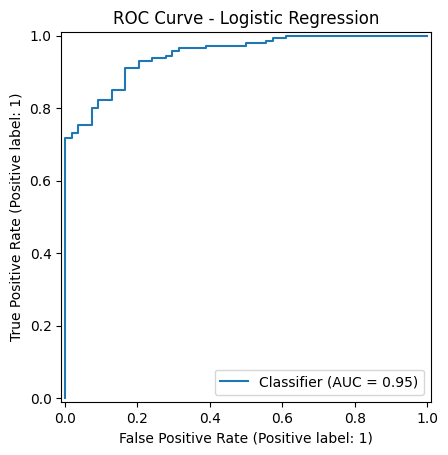


Random Forest

Accuracy : 0.945
Precision: 0.9299363057324841
Recall   : 1.0
ROC AUC  : 0.9992389649923896

Confusion Matrix
[[ 43  11]
 [  0 146]]


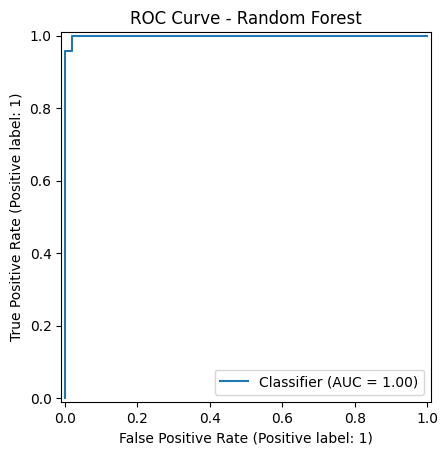


XGBoost

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
ROC AUC  : 1.0

Confusion Matrix
[[ 54   0]
 [  0 146]]


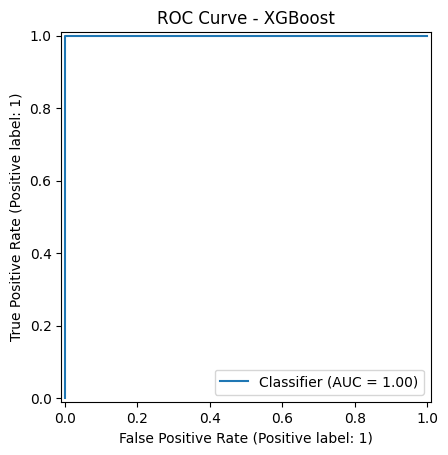

In [9]:
# Evaluation

def evaluate_model(model, X_test, y_test, name):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print()
    print(name)
    print()

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("ROC AUC  :", roc_auc_score(y_test, y_prob))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob
    )

    plt.title(f"ROC Curve - {name}")
    plt.show()

evaluate_model(
    lr_grid.best_estimator_,
    X_test,
    y_test,
    "Logistic Regression"
)

evaluate_model(
    rf_grid.best_estimator_,
    X_test,
    y_test,
    "Random Forest"
)

evaluate_model(
    xgb_grid.best_estimator_,
    X_test,
    y_test,
    "XGBoost"
)

In [10]:
results = []

models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

for name, model in models.items():

    # Training set
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    results.append({
        "Model": name,
        "Dataset": "Train",
        "Accuracy": accuracy_score(y_train, y_train_pred),
        "Precision": precision_score(y_train, y_train_pred),
        "Recall": recall_score(y_train, y_train_pred),
        "ROC-AUC": roc_auc_score(y_train, y_train_prob)
    })

    # Test set
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Dataset": "Test",
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc_score(y_test, y_test_prob)
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model Dataset  Accuracy  Precision    Recall   ROC-AUC
0  Logistic Regression   Train   0.88375   0.900327  0.945111  0.956557
1  Logistic Regression    Test   0.87500   0.875776  0.965753  0.947742
2        Random Forest   Train   0.99000   0.986464  1.000000  0.999984
3        Random Forest    Test   0.94500   0.929936  1.000000  0.999239
4              XGBoost   Train   1.00000   1.000000  1.000000  1.000000
5              XGBoost    Test   1.00000   1.000000  1.000000  1.000000


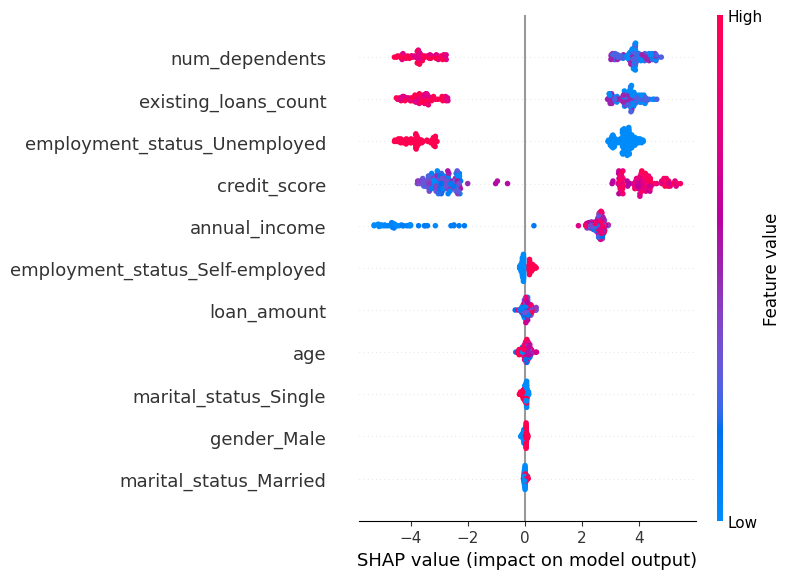

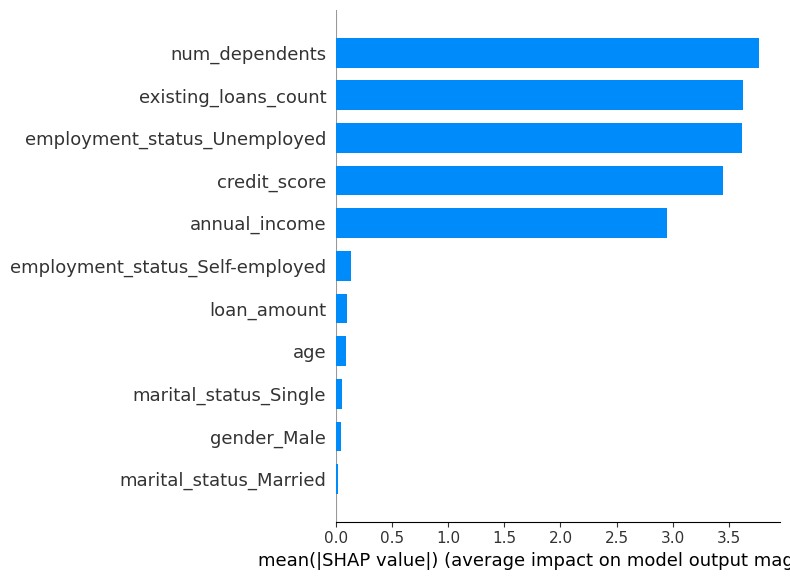

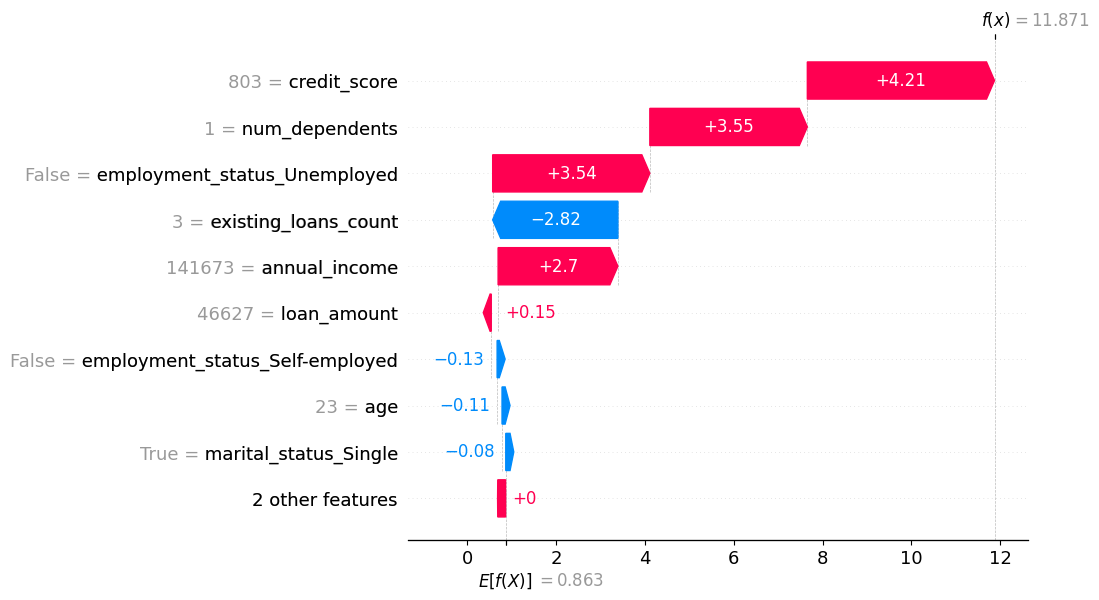

In [11]:
import shap
import matplotlib.pyplot as plt

best_model = xgb_grid.best_estimator_

explainer = shap.TreeExplainer(best_model)

shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

# Bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Waterfall plot
sample = 5

shap.plots.waterfall(shap_values[sample])


In [14]:
import joblib

joblib.dump(best_model, "loan_model.pkl")

joblib.dump(X.columns.tolist(), "features.pkl")

['features.pkl']